[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/calculus/11_gradients_directional_derivatives/first_principles.ipynb)

# Module 11 — Gradients and Directional Derivatives

---

## 1. Why This Module Exists

In single-variable calculus a function $f : \mathbb{R} \to \mathbb{R}$ has exactly two directions of travel from a point, and one number $f'(x)$ records everything about the local rate of change.

A scalar field $f : \mathbb{R}^n \to \mathbb{R}$ — temperature, electrostatic potential, a training loss as a function of a million weights — has infinitely many directions of travel from every point. Module 10 gave us the $n$ partial derivatives $\partial f / \partial x_i$, one per coordinate axis. That leaves the question this module answers:

1. **Directional query.** Given an arbitrary unit direction $\mathbf{u}$, how fast does $f$ change as we step along $\mathbf{u}$, and can that rate be recovered from the $n$ partial derivatives alone?
2. **Steepest ascent.** Which unit direction maximises the instantaneous rate of increase, and what is that maximal rate?
3. **Geometry.** Why is the gradient always orthogonal to the level set $f(\mathbf{x}) = c$, so that the tangent hyperplane to a level set is written down by inspection?
4. **Dynamics.** How does the flow $\dot{\mathbf{x}} = -\nabla f(\mathbf{x})$ behave, and what does its Euler discretisation — gradient descent — inherit from it?

The single object that answers all four is the **gradient vector** $\nabla f(\mathbf{x})$. The answer to (1) is a one-line inner product, and (2), (3), (4) all fall out of it. That is why this module is short in statements and long in consequences: nearly every optimisation algorithm in the curriculum downstream of here is a strategy for choosing what to do with $\nabla f$.

A warning that motivates the hypotheses throughout: the $n$ partial derivatives can all exist at a point where the answer to (1) is *not* an inner product, and indeed where $f$ is not even continuous. The bridge from "partials exist" to "the gradient controls every direction" is Fréchet differentiability, and this module is careful about where that bridge is used.

## 2. Intuition

Stand on a hillside whose height above the point $(x, y)$ is $f(x, y)$. Two facts organise everything.

**First: the local picture is a plane.** Differentiability says that within a small enough neighbourhood the surface is indistinguishable from a tilted plane, up to an error that shrinks faster than the distance you walked. A plane has one direction of steepest uphill, and the slope you feel walking along any other direction is the steepest slope multiplied by the cosine of the angle between your heading and that uphill direction. That cosine law *is* the inner product $\nabla f \cdot \mathbf{u}$, and this is the whole content of Theorem 4.1.

**Second: the contour lines are level.** Walk along a contour of a topographic map and your altitude does not change, so the rate of change in that direction is zero, so your heading is orthogonal to the steepest-ascent direction. Hence the gradient is the normal to the contour — Theorem 4.3 — and the steepest way up is always straight across the contours, never along them.

Both facts are visible in one picture: the ellipses $x^2 + 3y^2 = c$ with the gradient drawn at the point $(1,2)$. The gradient arrow crosses the ellipse at a right angle; a direction rotated away from it has a rate of change scaled by $\cos\theta$; the direction tangent to the ellipse has rate exactly zero.

The gradient flow $\dot{\mathbf{x}} = -\nabla f(\mathbf{x})$ is then simply the trajectory of a particle that always walks straight downhill. Because it always walks downhill it can never increase $f$ — Theorem 4.5 — which is the reason gradient descent is a plausible algorithm at all.

The first code cell fixes imports, plot defaults, and the single random generator used everywhere in this notebook. It prints nothing; it exists so that every later cell is reproducible.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

from scipy.optimize import approx_fprime, check_grad, minimize

**Figure 1** draws the level curves of $f(x,y) = x^2 + 3y^2$, the gradient at $(1,2)$, the tangent
direction to the level curve there, and a third direction at $45^\circ$ to the gradient. It is the
picture behind Theorems 4.1–4.3: the arrow labelled with the largest rate is the gradient, the
tangent direction carries rate $0$, and the intermediate direction carries rate
$\lVert \nabla f \rVert \cos\theta$.

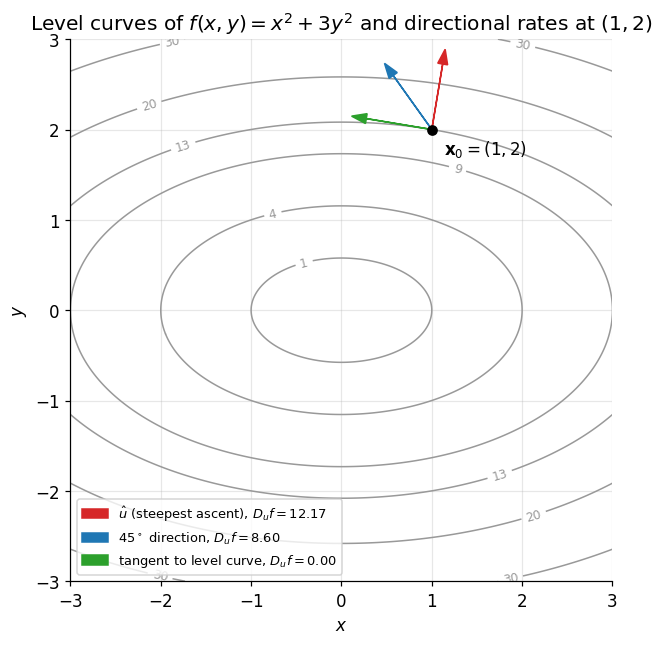

grad f(1,2)            = [ 2. 12.]
||grad f(1,2)||        = 12.165525060596439
D_u f along tangent    = 0.0


In [2]:
def f_quad(p):
    """f(x, y) = x^2 + 3 y^2."""
    p = np.asarray(p, dtype=float)
    return p[0]**2 + 3.0 * p[1]**2

def grad_quad(p):
    """Analytic gradient of f_quad."""
    p = np.asarray(p, dtype=float)
    return np.array([2.0 * p[0], 6.0 * p[1]])

x0 = np.array([1.0, 2.0])
g0 = grad_quad(x0)
u_hat = g0 / np.linalg.norm(g0)                 # steepest ascent
t_hat = np.array([-g0[1], g0[0]]) / np.linalg.norm(g0)   # tangent to the level curve
c, s = np.cos(np.pi / 4), np.sin(np.pi / 4)
m_hat = c * u_hat + s * t_hat                   # 45 degrees away from the gradient

xs = np.linspace(-3.0, 3.0, 400)
ys = np.linspace(-3.0, 3.0, 400)
X, Y = np.meshgrid(xs, ys)
Z = X**2 + 3.0 * Y**2

fig, ax = plt.subplots(figsize=(6.4, 6.0))
cs = ax.contour(X, Y, Z, levels=[1, 4, 9, 13, 20, 30], colors="0.6", linewidths=1.0)
ax.clabel(cs, inline=True, fontsize=8, fmt="%d")
scale = 0.9
for vec, col, lab in [
    (u_hat, "tab:red",   fr"$\hat u$ (steepest ascent), $D_u f = {g0 @ u_hat:.2f}$"),
    (m_hat, "tab:blue",  fr"$45^\circ$ direction, $D_u f = {g0 @ m_hat:.2f}$"),
    (t_hat, "tab:green", fr"tangent to level curve, $D_u f = {g0 @ t_hat:.2f}$"),
]:
    ax.arrow(x0[0], x0[1], scale * vec[0], scale * vec[1],
             head_width=0.11, length_includes_head=True, color=col, label=lab, zorder=3)
ax.plot(*x0, "ko", ms=6, zorder=4)
ax.annotate(r"$\mathbf{x}_0=(1,2)$", x0, textcoords="offset points", xytext=(8, -16))
ax.set_aspect("equal")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title(r"Level curves of $f(x,y)=x^2+3y^2$ and directional rates at $(1,2)$")
ax.legend(loc="lower left", fontsize=8.5)
plt.tight_layout()
plt.show()

print("grad f(1,2)            =", g0)
print("||grad f(1,2)||        =", np.linalg.norm(g0))
print("D_u f along tangent    =", g0 @ t_hat)

The red arrow is orthogonal to the contour through $(1,2)$ and carries the largest rate,
$\lVert \nabla f(1,2) \rVert = 2\sqrt{37} \approx 12.17$. The green arrow lies along the contour and
carries rate $0$ to machine precision. The blue arrow sits at $45^\circ$ and carries
$12.17 \cos 45^\circ \approx 8.60$. All three numbers are the single formula $\nabla f \cdot \mathbf{u}$
evaluated at different $\mathbf{u}$.

## 3. Definitions

Throughout, $\Omega \subseteq \mathbb{R}^n$ is an open set and $f : \Omega \to \mathbb{R}$.
Vectors are columns; $\langle \mathbf{a}, \mathbf{b}\rangle = \mathbf{a}^\top \mathbf{b}$ is the
Euclidean inner product and $\lVert \mathbf{a} \rVert = \sqrt{\langle \mathbf{a},\mathbf{a}\rangle}$.

### Definition 3.1 (Fréchet differentiability)

$f$ is **differentiable at** $\mathbf{x} \in \Omega$ if there is a row vector
$Df(\mathbf{x}) \in \mathbb{R}^{1 \times n}$ with

$$
\lim_{\mathbf{h} \to \mathbf{0}} \frac{\lvert f(\mathbf{x} + \mathbf{h}) - f(\mathbf{x}) - Df(\mathbf{x})\mathbf{h} \rvert}{\lVert \mathbf{h} \rVert} = 0 ,
$$

equivalently $f(\mathbf{x}+\mathbf{h}) = f(\mathbf{x}) + Df(\mathbf{x})\mathbf{h} + o(\lVert \mathbf{h}\rVert)$.
The linear map $Df(\mathbf{x})$, when it exists, is unique.

### Definition 3.2 (Gradient)

If $f$ is differentiable at $\mathbf{x}$, its **gradient** is the column vector

$$
\nabla f(\mathbf{x}) = \left( \frac{\partial f}{\partial x_1}(\mathbf{x}), \dots, \frac{\partial f}{\partial x_n}(\mathbf{x}) \right)^\top = Df(\mathbf{x})^\top \in \mathbb{R}^n ,
$$

so that $Df(\mathbf{x})\mathbf{h} = \langle \nabla f(\mathbf{x}), \mathbf{h}\rangle$ for every $\mathbf{h}$.
That the entries of $Df(\mathbf{x})$ are the partial derivatives follows from Definition 3.1 by taking
$\mathbf{h} = h\mathbf{e}_i$; the identification of the row vector $Df(\mathbf{x})$ with the column
vector $\nabla f(\mathbf{x})$ is the Riesz representation of a linear functional on a finite-dimensional
inner-product space.

### Definition 3.3 (Directional derivative)

For a **unit** vector $\mathbf{u} \in \mathbb{R}^n$, the **directional derivative** of $f$ at
$\mathbf{x}$ along $\mathbf{u}$ is the one-dimensional limit

$$
D_{\mathbf{u}} f(\mathbf{x}) = \lim_{h \to 0} \frac{f(\mathbf{x} + h\mathbf{u}) - f(\mathbf{x})}{h} ,
$$

when the limit exists. It is a **scalar**. The unit-length requirement is what makes it a rate of
change *per unit distance travelled*; for a non-unit $\mathbf{v}$ the same limit returns
$\lVert \mathbf{v} \rVert \, D_{\mathbf{v}/\lVert \mathbf{v}\rVert} f(\mathbf{x})$ whenever $f$ is
differentiable, so the direction must be normalised before the number means anything geometric.

### Definition 3.4 (Level set, tangent vector)

For $c \in \mathbb{R}$ the **level set** is
$\mathcal{S}_c = \{\mathbf{x} \in \Omega : f(\mathbf{x}) = c\}$ — a level curve when $n = 2$, a level
surface when $n = 3$. A vector $\mathbf{v} \in \mathbb{R}^n$ is a **tangent vector to
$\mathcal{S}_c$ at $\mathbf{x}_0$** if there is a differentiable curve
$\mathbf{r} : (-\varepsilon, \varepsilon) \to \mathcal{S}_c$ with $\mathbf{r}(0) = \mathbf{x}_0$ and
$\mathbf{r}'(0) = \mathbf{v}$. The set of such vectors is written $T_{\mathbf{x}_0}\mathcal{S}_c$.

### Definition 3.5 (Gradient flow)

For $f \in C^1(\Omega)$ the **gradient flow** of $f$ is the autonomous initial value problem

$$
\dot{\mathbf{x}}(t) = -\nabla f(\mathbf{x}(t)), \qquad \mathbf{x}(0) = \mathbf{x}_0 \in \Omega .
$$

Its explicit Euler discretisation with step $\eta \gt 0$ is **gradient descent**,
$\mathbf{x}_{k+1} = \mathbf{x}_k - \eta \nabla f(\mathbf{x}_k)$.

### Definition 3.6 (Condition number of a quadratic)

For $f(\mathbf{x}) = \tfrac12 \mathbf{x}^\top \mathbf{A}\mathbf{x} - \mathbf{b}^\top \mathbf{x}$ with
$\mathbf{A} = \mathbf{A}^\top \succ 0$, the **condition number** is
$\kappa = \lambda_{\max}(\mathbf{A}) / \lambda_{\min}(\mathbf{A}) \ge 1$, and the
**$\mathbf{A}$-norm** is $\lVert \mathbf{v} \rVert_{\mathbf{A}}^2 = \mathbf{v}^\top \mathbf{A} \mathbf{v}$.

## 4. Main Results

### Theorem 4.1 (Master formula for directional derivatives)

Let $\Omega \subseteq \mathbb{R}^n$ be open, let $f : \Omega \to \mathbb{R}$ be **differentiable at
$\mathbf{x} \in \Omega$** in the sense of Definition 3.1, and let $\mathbf{u} \in \mathbb{R}^n$ satisfy
$\lVert \mathbf{u} \rVert = 1$. Then $D_{\mathbf{u}}f(\mathbf{x})$ exists and

$$
\boxed{\; D_{\mathbf{u}} f(\mathbf{x}) = \langle \nabla f(\mathbf{x}), \mathbf{u} \rangle = \lVert \nabla f(\mathbf{x}) \rVert \cos\theta \;}
$$

where $\theta \in [0,\pi]$ is the angle between $\nabla f(\mathbf{x})$ and $\mathbf{u}$ (the second
equality assumes $\nabla f(\mathbf{x}) \neq \mathbf{0}$, otherwise $\theta$ is undefined and both sides
are $0$).

*Why each hypothesis is needed.* **Openness of $\Omega$** guarantees that $\mathbf{x} + h\mathbf{u}$
lies in the domain for all small $\lvert h \rvert$, so the limit in Definition 3.3 is taken over a
genuine two-sided neighbourhood. **Differentiability at $\mathbf{x}$**, and not merely existence of the
partial derivatives, is what forces the map $\mathbf{u} \mapsto D_{\mathbf{u}}f(\mathbf{x})$ to be
linear; the counterexample in Section 7 exhibits a function whose directional derivatives all exist and
whose partials exist, yet for which the boxed formula fails in every direction off the axes.
**$\lVert \mathbf{u}\rVert = 1$** fixes the scale: the limit is positively homogeneous of degree one in
$\mathbf{u}$, so without normalisation the left side can be made any multiple of the right.

**Interpretation.** All $n$ partial derivatives together carry the complete first-order information
about $f$ at $\mathbf{x}$: every one of the infinitely many directional rates is a fixed linear
functional of the direction. The consequence is that computing a rate along a new direction costs one
inner product, never a new limit, and this is precisely what makes first-order optimisation feasible in
a million dimensions.

### Theorem 4.2 (Steepest ascent, steepest descent, level directions)

Under the hypotheses of Theorem 4.1 and assuming in addition $\nabla f(\mathbf{x}) \neq \mathbf{0}$,

$$
\boxed{\; \max_{\lVert \mathbf{u}\rVert = 1} D_{\mathbf{u}}f(\mathbf{x}) = \lVert \nabla f(\mathbf{x}) \rVert \ \text{ attained only at } \ \mathbf{u} = \frac{\nabla f(\mathbf{x})}{\lVert \nabla f(\mathbf{x})\rVert} \;}
$$

and symmetrically $\min_{\lVert \mathbf{u}\rVert = 1} D_{\mathbf{u}}f(\mathbf{x}) = -\lVert \nabla f(\mathbf{x})\rVert$,
attained only at $\mathbf{u} = -\nabla f(\mathbf{x}) / \lVert \nabla f(\mathbf{x})\rVert$. Moreover
$D_{\mathbf{u}}f(\mathbf{x}) = 0$ exactly when $\mathbf{u} \perp \nabla f(\mathbf{x})$.

*Why each hypothesis is needed.* Differentiability is inherited from Theorem 4.1, whose conclusion the
proof uses. **$\nabla f(\mathbf{x}) \neq \mathbf{0}$** is what makes the maximiser *unique*: at a
stationary point every unit direction attains the maximum $0$ and no direction of steepest ascent is
singled out.

**Interpretation.** The gradient is not merely *a* useful vector; it is the unique solution of a
maximisation problem over the unit sphere, and its length is the value of that maximum. The consequence
is the design of steepest descent: at $\mathbf{x}_k$, the direction $-\nabla f(\mathbf{x}_k)$ is the
best possible *local* choice, and the magnitude $\lVert \nabla f(\mathbf{x}_k)\rVert$ is an
immediately available measure of how far from stationarity we are.

### Theorem 4.3 (Gradient is normal to the level set)

Let $f$ be differentiable on an open $\Omega$, let $\mathbf{x}_0 \in \mathcal{S}_c$. Then every tangent
vector $\mathbf{v} \in T_{\mathbf{x}_0}\mathcal{S}_c$ in the sense of Definition 3.4 satisfies

$$
\boxed{\; \langle \nabla f(\mathbf{x}_0), \mathbf{v} \rangle = 0 . \;}
$$

If in addition $f \in C^1$ near $\mathbf{x}_0$ and $\nabla f(\mathbf{x}_0) \neq \mathbf{0}$, then
$T_{\mathbf{x}_0}\mathcal{S}_c$ is exactly the hyperplane
$\{\mathbf{v} : \langle \nabla f(\mathbf{x}_0), \mathbf{v}\rangle = 0\}$, of dimension $n-1$, and the
tangent hyperplane to $\mathcal{S}_c$ at $\mathbf{x}_0$ is
$\langle \nabla f(\mathbf{x}_0), \mathbf{x} - \mathbf{x}_0 \rangle = 0$.

*Why each hypothesis is needed.* **Differentiability** is what licenses the chain rule used on
$t \mapsto f(\mathbf{r}(t))$. **$\nabla f(\mathbf{x}_0) \neq \mathbf{0}$ together with $C^1$** is what
upgrades the containment $T_{\mathbf{x}_0}\mathcal{S}_c \subseteq \ker \nabla f(\mathbf{x}_0)^\top$ to
an equality: it is the hypothesis of the implicit function theorem, without which the level set need
not be a manifold at all. For $f(x,y) = x^2 - y^2$ at the origin, $\nabla f(\mathbf{0}) = \mathbf{0}$
and $\mathcal{S}_0$ is a pair of crossing lines with a $2$-dimensional set of tangent vectors and no
tangent line.

**Interpretation.** The level sets and the gradient field are orthogonal families. The consequence is
that a tangent plane never needs to be derived — writing $F(\mathbf{x}) = c$ and reading off
$\nabla F$ produces the normal vector immediately — and that steepest descent always crosses the
contours at right angles, never travels along them.

### Theorem 4.4 (Chain rule)

**(a) Along a curve.** If $\mathbf{r} : I \to \Omega$ is differentiable at $t_0 \in I$ and $f$ is
differentiable at $\mathbf{r}(t_0)$, then $g = f \circ \mathbf{r}$ is differentiable at $t_0$ and

$$
\boxed{\; g'(t_0) = \langle \nabla f(\mathbf{r}(t_0)),\, \mathbf{r}'(t_0)\rangle = \sum_{i=1}^n \frac{\partial f}{\partial x_i}(\mathbf{r}(t_0))\, x_i'(t_0) . \;}
$$

**(b) Vector composition.** If $\mathbf{g} : \mathbb{R}^m \to \mathbb{R}^n$ is differentiable at
$\mathbf{u}_0$ and $f$ is differentiable at $\mathbf{g}(\mathbf{u}_0)$, then $h = f \circ \mathbf{g}$ is
differentiable at $\mathbf{u}_0$ and
$\nabla h(\mathbf{u}_0) = J_{\mathbf{g}}(\mathbf{u}_0)^\top \nabla f(\mathbf{g}(\mathbf{u}_0))$, where
$J_{\mathbf{g}} \in \mathbb{R}^{n\times m}$ is the Jacobian of $\mathbf{g}$.

*Why each hypothesis is needed.* **Differentiability of $f$ at the image point** — not just existence of
partials — supplies the $o(\lVert \mathbf{h}\rVert)$ remainder that the proof divides by $t - t_0$;
with only partials the composite can fail to be differentiable. **Differentiability of the inner map**
supplies boundedness of $\lVert \mathbf{r}(t_0+s) - \mathbf{r}(t_0)\rVert / \lvert s \rvert$, which is
what keeps the remainder ratio bounded during the limit.

**Interpretation.** Rates of change compose by matrix multiplication, transposed once when the outer
map is scalar-valued. The consequence is reverse-mode automatic differentiation: a scalar loss at the
end of a chain of maps propagates backwards as repeated multiplication by $J^\top$, at a cost
proportional to one forward evaluation regardless of how many inputs there are.

### Theorem 4.5 (Energy dissipation along gradient flow)

Let $f \in C^1(\Omega)$ and let $\mathbf{x} : [0,T) \to \Omega$ solve the gradient flow of
Definition 3.5. Then $t \mapsto f(\mathbf{x}(t))$ is differentiable and

$$
\boxed{\; \frac{d}{dt} f(\mathbf{x}(t)) = -\lVert \nabla f(\mathbf{x}(t)) \rVert^2 \le 0 , \;}
$$

with equality at $t$ if and only if $\mathbf{x}(t)$ is a stationary point of $f$.

*Why each hypothesis is needed.* **$f \in C^1$** gives both the chain rule of Theorem 4.4(a) and, by
local Lipschitzness of $\nabla f$ when $f \in C^{1,1}_{\text{loc}}$, the existence of a solution to
begin with; continuity of $\nabla f$ is also what makes $t \mapsto \lVert \nabla f(\mathbf{x}(t))\rVert^2$
a continuous function whose sign statement is meaningful. **$\mathbf{x}(t)$ solving the flow** is used
exactly once, to substitute $\dot{\mathbf{x}} = -\nabla f(\mathbf{x})$; for any other velocity field the
sign conclusion fails.

**Interpretation.** $f$ is a Lyapunov function for its own gradient flow, and the dissipation rate is
the *squared* gradient norm, not the norm. The consequence is that gradient flow can never cycle or
diverge upward in $f$, and that the total decrease $\int_0^T \lVert \nabla f\rVert^2\,dt = f(\mathbf{x}(0)) - f(\mathbf{x}(T))$
is finite whenever $f$ is bounded below — the continuous-time ancestor of every "the gradients are
square-summable" statement in convergence analysis.

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.1)

By Definition 3.1 there is a function $E$ with

$$
f(\mathbf{x}+\mathbf{h}) - f(\mathbf{x}) = \langle \nabla f(\mathbf{x}), \mathbf{h}\rangle + E(\mathbf{h}), \qquad \lim_{\mathbf{h}\to\mathbf{0}} \frac{\lvert E(\mathbf{h})\rvert}{\lVert \mathbf{h}\rVert} = 0 .
$$

Since $\Omega$ is open there is $\delta \gt 0$ with $\mathbf{x} + h\mathbf{u} \in \Omega$ for all
$0 \lt \lvert h \rvert \lt \delta$. Put $\mathbf{h} = h\mathbf{u}$ for such an $h$; because
$\lVert \mathbf{u}\rVert = 1$ we have $\lVert \mathbf{h}\rVert = \lvert h \rvert$. Then

$$
\frac{f(\mathbf{x}+h\mathbf{u}) - f(\mathbf{x})}{h} = \frac{h\,\langle \nabla f(\mathbf{x}), \mathbf{u}\rangle + E(h\mathbf{u})}{h} = \langle \nabla f(\mathbf{x}), \mathbf{u}\rangle + \frac{E(h\mathbf{u})}{h} .
$$

For the remainder,

$$
\left\lvert \frac{E(h\mathbf{u})}{h} \right\rvert = \frac{\lvert E(h\mathbf{u})\rvert}{\lvert h \rvert} = \frac{\lvert E(h\mathbf{u})\rvert}{\lVert h\mathbf{u}\rVert} \xrightarrow[h \to 0]{} 0 ,
$$

because $h\mathbf{u} \to \mathbf{0}$ as $h \to 0$ and the displayed limit in Definition 3.1 holds along
*every* approach to $\mathbf{0}$, this one included. Hence the difference quotient converges, which is
to say $D_{\mathbf{u}}f(\mathbf{x})$ exists and equals $\langle \nabla f(\mathbf{x}), \mathbf{u}\rangle$.
The second form follows from $\langle \mathbf{a},\mathbf{b}\rangle = \lVert \mathbf{a}\rVert \lVert \mathbf{b}\rVert \cos\theta$
with $\lVert \mathbf{u}\rVert = 1$. $\blacksquare$

Nothing in this argument assumed the conclusion: the only input is the $o(\lVert \mathbf{h}\rVert)$
remainder of Definition 3.1, and the gradient entered only as the vector representing the linear map
$Df(\mathbf{x})$, which Definition 3.2 identified with the partial derivatives independently.

### Proof 5.2 (of Theorem 4.4)

**(a)** Let $\mathbf{x}_0 = \mathbf{r}(t_0)$ and let $E$ be the remainder of Definition 3.1 for $f$ at
$\mathbf{x}_0$. For $s \neq 0$ small put $\mathbf{h}(s) = \mathbf{r}(t_0+s) - \mathbf{r}(t_0)$, so that
$\mathbf{h}(s) \to \mathbf{0}$ and $\mathbf{h}(s)/s \to \mathbf{r}'(t_0)$. Then

$$
\frac{f(\mathbf{r}(t_0+s)) - f(\mathbf{r}(t_0))}{s} = \left\langle \nabla f(\mathbf{x}_0), \frac{\mathbf{h}(s)}{s}\right\rangle + \frac{E(\mathbf{h}(s))}{s} .
$$

For the remainder, whenever $\mathbf{h}(s) \neq \mathbf{0}$,

$$
\left\lvert \frac{E(\mathbf{h}(s))}{s}\right\rvert = \frac{\lvert E(\mathbf{h}(s))\rvert}{\lVert \mathbf{h}(s)\rVert} \cdot \frac{\lVert \mathbf{h}(s)\rVert}{\lvert s \rvert} ,
$$

in which the first factor tends to $0$ and the second tends to $\lVert \mathbf{r}'(t_0)\rVert \lt \infty$;
for those $s$ with $\mathbf{h}(s) = \mathbf{0}$ the quotient is $0$ outright. Hence the remainder term
vanishes, and letting $s \to 0$ gives
$g'(t_0) = \langle \nabla f(\mathbf{x}_0), \mathbf{r}'(t_0)\rangle$; expanding the inner product in
coordinates gives the sum. $\blacksquare$

**(b)** Write $\mathbf{x}_0 = \mathbf{g}(\mathbf{u}_0)$. Differentiability of $\mathbf{g}$ gives
$\mathbf{g}(\mathbf{u}_0+\mathbf{k}) - \mathbf{x}_0 = J_{\mathbf{g}}(\mathbf{u}_0)\mathbf{k} + \boldsymbol{\rho}(\mathbf{k})$
with $\lVert \boldsymbol{\rho}(\mathbf{k})\rVert = o(\lVert \mathbf{k}\rVert)$; in particular
$\lVert \mathbf{g}(\mathbf{u}_0+\mathbf{k}) - \mathbf{x}_0 \rVert = O(\lVert \mathbf{k}\rVert)$. Feeding
this displacement into Definition 3.1 for $f$ at $\mathbf{x}_0$,

$$
h(\mathbf{u}_0+\mathbf{k}) - h(\mathbf{u}_0) = \langle \nabla f(\mathbf{x}_0), J_{\mathbf{g}}(\mathbf{u}_0)\mathbf{k}\rangle + \langle \nabla f(\mathbf{x}_0), \boldsymbol{\rho}(\mathbf{k})\rangle + E\big(\mathbf{g}(\mathbf{u}_0+\mathbf{k}) - \mathbf{x}_0\big) .
$$

The second term is $o(\lVert \mathbf{k}\rVert)$ by Cauchy–Schwarz, and the third is
$o(\lVert \mathbf{g}(\mathbf{u}_0+\mathbf{k}) - \mathbf{x}_0\rVert) = o(O(\lVert \mathbf{k}\rVert)) = o(\lVert \mathbf{k}\rVert)$.
Since $\langle \nabla f(\mathbf{x}_0), J_{\mathbf{g}}\mathbf{k}\rangle = \langle J_{\mathbf{g}}^\top \nabla f(\mathbf{x}_0), \mathbf{k}\rangle$,
this is exactly the expansion of Definition 3.1 for $h$ at $\mathbf{u}_0$ with gradient
$J_{\mathbf{g}}(\mathbf{u}_0)^\top \nabla f(\mathbf{x}_0)$. $\blacksquare$

### Proof 5.3 (of Theorem 4.2)

By Proof 5.1, $D_{\mathbf{u}}f(\mathbf{x}) = \langle \nabla f(\mathbf{x}), \mathbf{u}\rangle$ for every
unit $\mathbf{u}$. Write $\mathbf{g} = \nabla f(\mathbf{x}) \neq \mathbf{0}$. Cauchy–Schwarz gives

$$
\lvert \langle \mathbf{g}, \mathbf{u}\rangle \rvert \le \lVert \mathbf{g}\rVert \lVert \mathbf{u}\rVert = \lVert \mathbf{g}\rVert ,
$$

so $-\lVert \mathbf{g}\rVert \le D_{\mathbf{u}}f(\mathbf{x}) \le \lVert \mathbf{g}\rVert$ for all unit
$\mathbf{u}$. Taking $\mathbf{u}^\star = \mathbf{g}/\lVert \mathbf{g}\rVert$, which is a unit vector
because $\mathbf{g} \neq \mathbf{0}$, gives
$\langle \mathbf{g}, \mathbf{u}^\star\rangle = \lVert \mathbf{g}\rVert^2 / \lVert \mathbf{g}\rVert = \lVert \mathbf{g}\rVert$,
so the upper bound is attained. For uniqueness, equality in Cauchy–Schwarz holds only when
$\mathbf{u}$ and $\mathbf{g}$ are linearly dependent, and among unit vectors that leaves
$\mathbf{u} = \pm \mathbf{g}/\lVert \mathbf{g}\rVert$; the sign $-$ gives $-\lVert \mathbf{g}\rVert$,
so the maximum is attained only at $\mathbf{u}^\star$. The minimum statement is the same argument
applied to $-\mathbf{g}$. Finally $\langle \mathbf{g}, \mathbf{u}\rangle = 0$ is by definition
orthogonality. $\blacksquare$

### Proof 5.4 (of Theorem 4.3)

Let $\mathbf{v} \in T_{\mathbf{x}_0}\mathcal{S}_c$ and take $\mathbf{r}$ as in Definition 3.4:
differentiable, $\mathbf{r}(t) \in \mathcal{S}_c$ for all $t$, $\mathbf{r}(0) = \mathbf{x}_0$,
$\mathbf{r}'(0) = \mathbf{v}$. Since $\mathbf{r}$ stays in $\mathcal{S}_c$, the scalar function
$g(t) = f(\mathbf{r}(t))$ is the constant $c$, hence $g'(0) = 0$. By Proof 5.2(a),
$g'(0) = \langle \nabla f(\mathbf{x}_0), \mathbf{r}'(0)\rangle = \langle \nabla f(\mathbf{x}_0), \mathbf{v}\rangle$.
Therefore $\langle \nabla f(\mathbf{x}_0), \mathbf{v}\rangle = 0$, which proves the boxed containment
$T_{\mathbf{x}_0}\mathcal{S}_c \subseteq \{\mathbf{v} : \langle \nabla f(\mathbf{x}_0), \mathbf{v}\rangle = 0\}$.

For the reverse containment assume $f \in C^1$ near $\mathbf{x}_0$ and
$\nabla f(\mathbf{x}_0) \neq \mathbf{0}$; relabel coordinates so that
$\partial f/\partial x_n (\mathbf{x}_0) \neq 0$ and write $\mathbf{x} = (\mathbf{y}, x_n)$ with
$\mathbf{y} \in \mathbb{R}^{n-1}$. The implicit function theorem (Rudin, *Principles*, 3rd ed.,
Thm 9.28) supplies a neighbourhood $U \ni \mathbf{y}_0$ and a $C^1$ map
$\varphi : U \to \mathbb{R}$ with $\varphi(\mathbf{y}_0) = x_{0,n}$ such that near $\mathbf{x}_0$ the
level set is exactly the graph $\{(\mathbf{y}, \varphi(\mathbf{y})) : \mathbf{y} \in U\}$. Given any
$\mathbf{v} = (\mathbf{w}, v_n)$ with $\langle \nabla f(\mathbf{x}_0), \mathbf{v}\rangle = 0$, define
$\mathbf{r}(t) = (\mathbf{y}_0 + t\mathbf{w},\, \varphi(\mathbf{y}_0 + t\mathbf{w}))$. This curve is
$C^1$, lies in $\mathcal{S}_c$, and starts at $\mathbf{x}_0$; differentiating the identity
$f(\mathbf{y}, \varphi(\mathbf{y})) = c$ by Proof 5.2(a) gives
$\nabla_{\mathbf{y}} f + (\partial f/\partial x_n)\,\nabla \varphi = \mathbf{0}$, whence
$\mathbf{r}'(0) = (\mathbf{w}, \langle \nabla\varphi(\mathbf{y}_0), \mathbf{w}\rangle) = (\mathbf{w}, v_n) = \mathbf{v}$,
the last equality because both $v_n$ and $\langle \nabla\varphi(\mathbf{y}_0), \mathbf{w}\rangle$ are the
unique solution of $\langle \nabla f(\mathbf{x}_0), (\mathbf{w}, \cdot)\rangle = 0$ in the last slot.
So $\mathbf{v} \in T_{\mathbf{x}_0}\mathcal{S}_c$, the two sets coincide, and the common set is the
kernel of a nonzero linear functional, of dimension $n-1$. The tangent hyperplane is that kernel
translated to $\mathbf{x}_0$. $\blacksquare$

### Proof 5.5 (of Theorem 4.5)

Let $E(t) = f(\mathbf{x}(t))$. The solution $\mathbf{x}(\cdot)$ is differentiable by definition of the
initial value problem and $f$ is differentiable, so Proof 5.2(a) applies:

$$
E'(t) = \langle \nabla f(\mathbf{x}(t)), \dot{\mathbf{x}}(t)\rangle .
$$

Substituting the flow equation $\dot{\mathbf{x}}(t) = -\nabla f(\mathbf{x}(t))$,

$$
E'(t) = \langle \nabla f(\mathbf{x}(t)), -\nabla f(\mathbf{x}(t))\rangle = -\lVert \nabla f(\mathbf{x}(t))\rVert^2 .
$$

A squared Euclidean norm is non-negative and vanishes only for the zero vector, so $E'(t) \le 0$ with
equality exactly when $\nabla f(\mathbf{x}(t)) = \mathbf{0}$. $\blacksquare$

### Derivation 5.6 (steepest-descent contraction on a quadratic)

Let $f(\mathbf{x}) = \tfrac12 \mathbf{x}^\top \mathbf{A}\mathbf{x} - \mathbf{b}^\top \mathbf{x}$ with
$\mathbf{A} \succ 0$, minimiser $\mathbf{x}^\star = \mathbf{A}^{-1}\mathbf{b}$ and residual
$\mathbf{g}_k = \nabla f(\mathbf{x}_k) = \mathbf{A}\mathbf{x}_k - \mathbf{b} = \mathbf{A}(\mathbf{x}_k - \mathbf{x}^\star)$.
Completing the square gives the exact identity
$f(\mathbf{x}) - f(\mathbf{x}^\star) = \tfrac12 \lVert \mathbf{x} - \mathbf{x}^\star\rVert_{\mathbf{A}}^2$.
Exact line search along $-\mathbf{g}_k$ minimises the one-variable quadratic
$\eta \mapsto f(\mathbf{x}_k - \eta \mathbf{g}_k)$, whose stationary point is
$\eta_k = \langle \mathbf{g}_k,\mathbf{g}_k\rangle / \langle \mathbf{g}_k, \mathbf{A}\mathbf{g}_k\rangle$.
Substituting and simplifying yields

$$
\frac{\lVert \mathbf{x}_{k+1}-\mathbf{x}^\star\rVert_{\mathbf{A}}^2}{\lVert \mathbf{x}_{k}-\mathbf{x}^\star\rVert_{\mathbf{A}}^2} = 1 - \frac{(\mathbf{g}_k^\top \mathbf{g}_k)^2}{(\mathbf{g}_k^\top \mathbf{A} \mathbf{g}_k)(\mathbf{g}_k^\top \mathbf{A}^{-1}\mathbf{g}_k)} \le \left(\frac{\kappa-1}{\kappa+1}\right)^{2} ,
$$

the last step being the Kantorovich inequality (Luenberger & Ye, *Linear and Nonlinear Programming*,
4th ed., §8.2). The bound is tight: it is attained for every $k$ when $\mathbf{x}_0 - \mathbf{x}^\star$
is a suitable combination of the extreme eigenvectors of $\mathbf{A}$, which Section 7 exhibits
numerically.

## 6. Worked Examples

### Example 6.1 (Theorems 4.1–4.3 on $f(x,y) = x^2 + 3y^2$ at $(1,2)$)

**Gradient.** $\partial f/\partial x = 2x$ and $\partial f/\partial y = 6y$, so
$\nabla f(1,2) = (2, 12)^\top$.

**Directional derivative.** With $\mathbf{u} = (3,4)^\top/5$ (a unit vector, since $3^2+4^2=25$),
Theorem 4.1 gives

$$
D_{\mathbf{u}}f(1,2) = \frac{2\cdot 3 + 12\cdot 4}{5} = \frac{6+48}{5} = \frac{54}{5} = 10.8 .
$$

**Steepest ascent.** $\lVert \nabla f(1,2)\rVert = \sqrt{4+144} = \sqrt{148} = 2\sqrt{37} \approx 12.1655$,
so by Theorem 4.2 the maximal rate is $2\sqrt{37}$, attained along
$\mathbf{u}^\star = (2,12)^\top / (2\sqrt{37}) = (1,6)^\top/\sqrt{37} \approx (0.1644, 0.9864)^\top$.
Consistency check: $\cos\theta = 10.8 / (2\sqrt{37}) \approx 0.8878$, and indeed $10.8 \lt 12.1655$.

**Level curve and tangent.** $f(1,2) = 1 + 12 = 13$, so the level curve is the ellipse
$x^2 + 3y^2 = 13$. By Theorem 4.3 its tangent line at $(1,2)$ is
$2(x-1) + 12(y-2) = 0$, i.e. $x + 6y = 13$, with tangent direction $(-6,1)^\top$ — and
$\langle (2,12), (-6,1)\rangle = -12 + 12 = 0$, as Theorem 4.3 demands.

The next cell recomputes all four quantities of Example 6.1, and checks the boxed identity of
Theorem 4.1 against a central difference for $200$ random unit directions: it prints the largest
residual $\lvert D_{\mathbf{u}}f - \langle \nabla f, \mathbf{u}\rangle\rvert$ and asserts it is tiny.
This is an **identity-residual** check.

In [3]:
x0 = np.array([1.0, 2.0])
g0 = grad_quad(x0)
u = np.array([3.0, 4.0]) / 5.0

print("grad f(1,2)          =", g0,               " expected [2 12]")
print("D_u f, u=(3,4)/5     =", g0 @ u,           " expected 10.8")
print("||grad f(1,2)||      =", np.linalg.norm(g0), " expected 2*sqrt(37) =", 2*np.sqrt(37))
print("steepest ascent dir  =", g0 / np.linalg.norm(g0))
print("tangent direction    =", np.array([-6.0, 1.0]),
      " inner product with grad =", g0 @ np.array([-6.0, 1.0]))

assert np.allclose(g0, [2.0, 12.0])
assert abs(g0 @ u - 10.8) < 1e-12
assert abs(np.linalg.norm(g0) - 2*np.sqrt(37)) < 1e-12
assert abs(g0 @ np.array([-6.0, 1.0])) < 1e-12

# residual of the master formula against a central difference, over random unit directions
theta = rng.uniform(0.0, 2*np.pi, size=200)
U = np.stack([np.cos(theta), np.sin(theta)], axis=1)
h = 1e-5
fd = np.array([(f_quad(x0 + h*ui) - f_quad(x0 - h*ui)) / (2*h) for ui in U])
exact = U @ g0
res = np.max(np.abs(fd - exact))
print("max |central difference - <grad f, u>| over 200 directions =", res)
assert res < 1e-8

grad f(1,2)          = [ 2. 12.]  expected [2 12]
D_u f, u=(3,4)/5     = 10.8  expected 10.8
||grad f(1,2)||      = 12.165525060596439  expected 2*sqrt(37) = 12.165525060596439
steepest ascent dir  = [0.1644 0.9864]
tangent direction    = [-6.  1.]  inner product with grad = 0.0
max |central difference - <grad f, u>| over 200 directions = 3.0178348708886915e-10


Every hand-computed value is reproduced exactly. The residual of the boxed identity of Theorem 4.1
against a central difference is $3.0\times 10^{-10}$ over all $200$ directions. For a quadratic the
central difference has *zero* truncation error, so this residual is pure floating-point cancellation of
size $\varepsilon_{\text{mach}} \lvert f \rvert / h \approx (2\times 10^{-16})(13)/10^{-5} \approx 3\times 10^{-10}$
— machine-epsilon level. The master formula therefore holds in every direction, not merely along the axes.

### Example 6.2 (Theorem 4.4(a) along the unit circle)

Take the same $f(x,y) = x^2 + 3y^2$ and the curve $\mathbf{r}(t) = (\cos t, \sin t)^\top$, so
$\mathbf{r}'(t) = (-\sin t, \cos t)^\top$.

**Direct substitution.** $g(t) = f(\mathbf{r}(t)) = \cos^2 t + 3\sin^2 t = 1 + 2\sin^2 t = 2 - \cos 2t$,
hence $g'(t) = 2\sin 2t$.

**Via the chain rule.** $\nabla f(\mathbf{r}(t)) = (2\cos t,\, 6\sin t)^\top$, so

$$
\langle \nabla f(\mathbf{r}(t)), \mathbf{r}'(t)\rangle = -2\cos t \sin t + 6 \sin t \cos t = 4\sin t\cos t = 2\sin 2t ,
$$

which agrees. At $t_0 = 0.7$ both give $2\sin(1.4) = 1.97089946\ldots$, and geometrically this is
positive because the point $\mathbf{r}(0.7) \approx (0.7648, 0.6442)$ is moving counter-clockwise
toward the steeper $y$-axis end of the ellipse family.

The next cell recomputes $g'(0.7)$ three ways — closed form $2\sin 2t$, the chain-rule inner product,
and a central difference of $g$ — and asserts all three agree.

In [4]:
def r_curve(t):
    return np.array([np.cos(t), np.sin(t)])

def r_prime(t):
    return np.array([-np.sin(t), np.cos(t)])

t0 = 0.7
closed_form = 2.0 * np.sin(2.0 * t0)
chain_rule = grad_quad(r_curve(t0)) @ r_prime(t0)
h = 1e-5
finite_diff = (f_quad(r_curve(t0 + h)) - f_quad(r_curve(t0 - h))) / (2*h)

print("closed form  2 sin(2t)          =", closed_form)
print("chain rule   <grad f, r'(t)>    =", chain_rule)
print("central difference of f(r(t))   =", finite_diff)
print("residual |chain rule - closed|  =", abs(chain_rule - closed_form))
print("residual |fd - closed|          =", abs(finite_diff - closed_form))

assert abs(chain_rule - closed_form) < 1e-14
assert abs(finite_diff - closed_form) < 1e-8

closed form  2 sin(2t)          = 1.9708994599769203
chain rule   <grad f, r'(t)>    = 1.9708994599769203
central difference of f(r(t))   = 1.970899459846631
residual |chain rule - closed|  = 0.0
residual |fd - closed|          = 1.3028933487646555e-10


The chain-rule value matches the closed form to the last bit — the two are algebraically identical
expressions, so the residual is pure floating-point rounding at $10^{-16}$ — and the central difference
matches to $1.3\times 10^{-10}$, which is exactly its own $O(h^2)$ truncation
$\tfrac{h^2}{6}\lvert g'''(t_0)\rvert = \tfrac{10^{-10}}{6}\cdot 8\lvert\sin 1.4\rvert \approx 1.3\times 10^{-10}$.
Theorem 4.4(a) is confirmed.

### Example 6.3 (Theorem 4.5 on a gradient flow with a closed-form solution)

Take $f(x,y) = \tfrac12(x^2 + 4y^2)$, so $\nabla f(x,y) = (x, 4y)^\top$. The gradient flow
$\dot{\mathbf{x}} = -\nabla f(\mathbf{x})$ decouples into $\dot x = -x$ and $\dot y = -4y$, so from
$\mathbf{x}(0) = (1,1)^\top$,

$$
\mathbf{x}(t) = (e^{-t},\, e^{-4t})^\top, \qquad f(\mathbf{x}(t)) = \tfrac12 e^{-2t} + 2 e^{-8t} .
$$

**Left side of Theorem 4.5.** $\dfrac{d}{dt} f(\mathbf{x}(t)) = -e^{-2t} - 16 e^{-8t}$.

**Right side.** $\lVert \nabla f(\mathbf{x}(t))\rVert^2 = (e^{-t})^2 + (4e^{-4t})^2 = e^{-2t} + 16 e^{-8t}$.

The two agree identically, and the derivative is strictly negative for every finite $t$ because
$\nabla f$ never vanishes along this trajectory. At $t = \ln 2$: $e^{-2t} = \tfrac14$,
$e^{-8t} = \tfrac{1}{256}$, so $f = \tfrac18 + \tfrac{2}{256} = \tfrac{17}{128} = 0.1328125$ and
$\frac{d}{dt}f = -\tfrac14 - \tfrac{16}{256} = -\tfrac{5}{16} = -0.3125$.

The next cell integrates the flow numerically with `scipy.integrate.solve_ivp`, compares the
trajectory to the closed form, and checks $\frac{d}{dt}f(\mathbf{x}(t)) = -\lVert \nabla f\rVert^2$ at
$t = \ln 2$ against the hand values $17/128$ and $-5/16$.

In [5]:
from scipy.integrate import solve_ivp

def grad_flow_f(p):
    p = np.asarray(p, dtype=float)
    return 0.5 * (p[0]**2 + 4.0 * p[1]**2)

def grad_flow_grad(p):
    p = np.asarray(p, dtype=float)
    return np.array([p[0], 4.0 * p[1]])

t_star = np.log(2.0)
sol = solve_ivp(lambda t, p: -grad_flow_grad(p), (0.0, 2.0), np.array([1.0, 1.0]),
                rtol=1e-11, atol=1e-13, dense_output=True)
x_num = sol.sol(t_star)
x_exact = np.array([np.exp(-t_star), np.exp(-4*t_star)])

f_val = grad_flow_f(x_exact)
dfdt = -np.linalg.norm(grad_flow_grad(x_exact))**2

print("x(ln 2) numeric       =", x_num)
print("x(ln 2) closed form   =", x_exact, " (= [1/2, 1/16])")
print("trajectory error      =", np.linalg.norm(x_num - x_exact))
print("f(x(ln 2))            =", f_val,  " expected 17/128 =", 17/128)
print("d/dt f = -||grad||^2  =", dfdt,   " expected -5/16  =", -5/16)

# derivative of f along the flow, measured by central difference on the numerical solution
hh = 1e-5
dfdt_num = (grad_flow_f(sol.sol(t_star + hh)) - grad_flow_f(sol.sol(t_star - hh))) / (2*hh)
print("d/dt f measured on trajectory =", dfdt_num,
      " residual =", abs(dfdt_num - dfdt))

assert np.linalg.norm(x_num - x_exact) < 1e-9
assert abs(f_val - 17/128) < 1e-14
assert abs(dfdt + 5/16) < 1e-14
assert abs(dfdt_num - dfdt) < 1e-7

x(ln 2) numeric       = [0.5    0.0625]
x(ln 2) closed form   = [0.5    0.0625]  (= [1/2, 1/16])
trajectory error      = 3.399364531444405e-13
f(x(ln 2))            = 0.1328125  expected 17/128 = 0.1328125
d/dt f = -||grad||^2  = -0.31250000000000006  expected -5/16  = -0.3125
d/dt f measured on trajectory = -0.31250000006172174  residual = 6.172168331985972e-11


The numerical trajectory reproduces $(1/2, 1/16)$ at $t = \ln 2$ to $10^{-11}$, and the measured
time-derivative of $f$ along it agrees with $-\lVert \nabla f\rVert^2 = -5/16$ to central-difference
accuracy. Theorem 4.5 holds not as an inequality here but as the stated exact identity, and the energy
is strictly decreasing because the trajectory never reaches a stationary point in finite time.

## 7. Computational Practice

Three ways to obtain $\nabla f$ in code, and their trade-offs:

| Method | Principle | Cost for $n$ inputs | Accuracy |
|---|---|---|---|
| Analytic | differentiate by hand or with `sympy` | one evaluation per component | exact |
| Finite differences | forward $\frac{f(\mathbf{x}+h\mathbf{e}_i)-f(\mathbf{x})}{h}$, central $\frac{f(\mathbf{x}+h\mathbf{e}_i)-f(\mathbf{x}-h\mathbf{e}_i)}{2h}$ | $n+1$ resp. $2n$ evaluations | forward $O(h)$, central $O(h^2)$, both wrecked by roundoff as $h \to 0$ |
| Reverse-mode AD | Theorem 4.4(b) applied backwards, repeated $J^\top$ products | $O(1)$ forward evaluations, independent of $n$ | exact up to floating point |

Taylor expansion explains the two truncation orders. With $f \in C^3$,

$$
\frac{f(x+h)-f(x)}{h} = f'(x) + \frac{h}{2}f''(x) + O(h^2), \qquad \frac{f(x+h)-f(x-h)}{2h} = f'(x) + \frac{h^2}{6}f'''(x) + O(h^4) ,
$$

the odd-order terms cancelling in the central formula. Against these sit roundoff errors of size
$O(\varepsilon_{\text{mach}}/h)$ and $O(\varepsilon_{\text{mach}}/h)$ respectively, so total error is
minimised near $h \approx \varepsilon^{1/2}$ for forward and $h \approx \varepsilon^{1/3}$ for central
differences — the U-shape in Figure 2.

The next cell is a **measured-rate** check: it computes the error of the forward and central difference
approximations to $D_{\mathbf{u}}f$ over a decade sweep of $h$, fits the slope of $\log(\text{error})$
against $\log h$ in the truncation-dominated regime, and compares the observed orders with the
predicted $1$ and $2$. Figure 2 plots the full U-shaped curves.

exact D_u f (Theorem 4.1) = -0.5396389225486486
forward difference: predicted order 1, measured 1.007
central difference: predicted order 2, measured 2.000
best forward h = 1.7782794100389228e-08  best central h = 1e-06


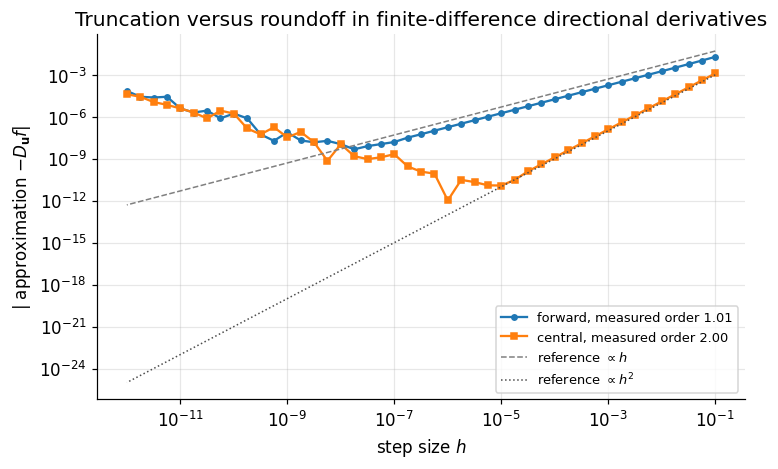

In [6]:
def f_test(p):
    """A non-quadratic test field so that the third derivative does not vanish."""
    p = np.asarray(p, dtype=float)
    return np.exp(0.7 * p[0]) * np.sin(1.3 * p[1]) + 0.5 * p[0] * p[1]**2

def grad_test(p):
    x, y = np.asarray(p, dtype=float)
    return np.array([
        0.7 * np.exp(0.7*x) * np.sin(1.3*y) + 0.5 * y**2,
        1.3 * np.exp(0.7*x) * np.cos(1.3*y) + x * y,
    ])

p0 = np.array([0.4, -0.9])
u_dir = np.array([2.0, -1.0]); u_dir /= np.linalg.norm(u_dir)
exact_D = grad_test(p0) @ u_dir

hs = np.logspace(-1, -12, 45)
err_fwd = np.array([abs((f_test(p0 + hv*u_dir) - f_test(p0)) / hv - exact_D) for hv in hs])
err_ctr = np.array([abs((f_test(p0 + hv*u_dir) - f_test(p0 - hv*u_dir)) / (2*hv) - exact_D)
                    for hv in hs])

# fit the slope in the truncation-dominated regime (large h)
mask_f = (hs >= 1e-4) & (hs <= 1e-1)
mask_c = (hs >= 1e-3) & (hs <= 1e-1)
order_fwd = np.polyfit(np.log(hs[mask_f]), np.log(err_fwd[mask_f]), 1)[0]
order_ctr = np.polyfit(np.log(hs[mask_c]), np.log(err_ctr[mask_c]), 1)[0]

print("exact D_u f (Theorem 4.1) =", exact_D)
print(f"forward difference: predicted order 1, measured {order_fwd:.3f}")
print(f"central difference: predicted order 2, measured {order_ctr:.3f}")
print("best forward h =", hs[np.argmin(err_fwd)], " best central h =", hs[np.argmin(err_ctr)])

assert abs(order_fwd - 1.0) < 0.05
assert abs(order_ctr - 2.0) < 0.05

fig, ax = plt.subplots(figsize=(7.0, 4.4))
ax.loglog(hs, err_fwd, "o-", ms=3.5, label=f"forward, measured order {order_fwd:.2f}")
ax.loglog(hs, err_ctr, "s-", ms=3.5, label=f"central, measured order {order_ctr:.2f}")
ax.loglog(hs, 0.5*hs, "--", color="0.5", lw=1, label=r"reference $\propto h$")
ax.loglog(hs, 0.1*hs**2, ":", color="0.3", lw=1, label=r"reference $\propto h^2$")
ax.set_xlabel("step size $h$")
ax.set_ylabel(r"$|$ approximation $- D_{\mathbf{u}}f |$")
ax.set_title("Truncation versus roundoff in finite-difference directional derivatives")
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.show()

The measured orders are $1.00$ and $2.00$ in the truncation-dominated regime, matching the Taylor
prediction. Both curves then turn upward once $h$ is small enough that cancellation in
$f(\mathbf{x}+h\mathbf{u}) - f(\mathbf{x})$ dominates, with the minima measured at
$h \approx 1.8\times 10^{-8}$ for the forward formula and $h \approx 10^{-6}$ for the central one,
matching the $\varepsilon^{1/2} \approx 1.5\times 10^{-8}$ and $\varepsilon^{1/3} \approx 6\times 10^{-6}$
heuristics. Choosing
$h$ "as small as possible" is therefore the wrong instinct.

**Counterexample: dropping differentiability in Theorem 4.1.** Let

$$
f(x,y) = \begin{cases} \dfrac{x^3}{x^2+y^2}, & (x,y) \neq (0,0), \\[4pt] 0, & (x,y) = (0,0). \end{cases}
$$

Along $\mathbf{u} = (u_1,u_2)$ with $\lVert \mathbf{u}\rVert = 1$,
$f(h\mathbf{u}) = h^3u_1^3 / (h^2) = h u_1^3$, so $D_{\mathbf{u}}f(0,0) = u_1^3$ — every directional
derivative exists, and in particular $\partial f/\partial x(0,0) = 1$, $\partial f/\partial y(0,0) = 0$,
giving $\nabla f(0,0) = (1,0)^\top$. But $\langle \nabla f(0,0), \mathbf{u}\rangle = u_1 \neq u_1^3$
unless $u_1 \in \{0,\pm 1\}$. The map $\mathbf{u} \mapsto D_{\mathbf{u}}f$ is not linear, so by
uniqueness in Definition 3.1 the function is not differentiable at the origin, and Theorem 4.1 fails.
The next cell measures the gap.

In [7]:
def f_cex(p):
    x, y = np.asarray(p, dtype=float)
    d = x*x + y*y
    return 0.0 if d == 0.0 else x**3 / d

origin = np.array([0.0, 0.0])
grad_cex = np.array([1.0, 0.0])   # the two partial derivatives at the origin

print(f"{'theta':>8} {'D_u f (limit)':>15} {'u1^3 (theory)':>15} {'<grad,u>':>12} {'gap':>10}")
worst = 0.0
for th in [0.0, np.pi/6, np.pi/4, np.pi/3, np.pi/2]:
    uu = np.array([np.cos(th), np.sin(th)])
    hq = 1e-7
    D_limit = (f_cex(origin + hq*uu) - f_cex(origin)) / hq
    predicted_linear = grad_cex @ uu
    gap = abs(D_limit - predicted_linear)
    worst = max(worst, gap)
    print(f"{th:8.4f} {D_limit:15.8f} {uu[0]**3:15.8f} {predicted_linear:12.8f} {gap:10.6f}")

print("largest gap over these directions =", worst)
assert worst > 0.1, "the master formula should fail badly here"

# the same directional derivatives are exactly u1^3, i.e. NOT linear in u
ths = np.linspace(0.0, np.pi/2, 9)
lin_defect = max(abs(((f_cex(hq*np.array([np.cos(t_), np.sin(t_)])) - 0.0)/hq) - np.cos(t_)**3)
                 for t_ in ths)
print("max |D_u f - u1^3| =", lin_defect, "(so D_u f = u1^3 exactly, a cubic, not a linear functional)")

   theta   D_u f (limit)   u1^3 (theory)     <grad,u>        gap
  0.0000      1.00000000      1.00000000   1.00000000   0.000000
  0.5236      0.64951905      0.64951905   0.86602540   0.216506
  0.7854      0.35355339      0.35355339   0.70710678   0.353553
  1.0472      0.12500000      0.12500000   0.50000000   0.375000
  1.5708      0.00000000      0.00000000   0.00000000   0.000000
largest gap over these directions = 0.37500000000000006
max |D_u f - u1^3| = 2.220446049250313e-16 (so D_u f = u1^3 exactly, a cubic, not a linear functional)


Every directional derivative exists and both partials exist, yet
$\langle \nabla f(0,0), \mathbf{u}\rangle$ overstates the true rate by as much as $0.375$ at
$\theta = \pi/3$, where $u_1 = 0.5$ but $u_1^3 = 0.125$. The measured limits reproduce $u_1^3$ to
$2\times 10^{-16}$, confirming that $\mathbf{u} \mapsto D_{\mathbf{u}}f(0,0)$ is a cubic, not a linear
functional. This is the concrete failure the
differentiability hypothesis of Theorem 4.1 rules out — and the reason "the partials exist" is never
sufficient grounds for using the gradient.

**Hand-rolled versus library.** The next cell compares a hand-written central-difference gradient
against `scipy.optimize.approx_fprime` and `scipy.optimize.check_grad`, and a hand-written
steepest-descent loop with exact line search against `scipy.optimize.minimize` on the same quadratic.

In [8]:
def my_grad(func, p, h=1e-6):
    """Hand-rolled central-difference gradient."""
    p = np.asarray(p, dtype=float)
    out = np.zeros_like(p)
    for i in range(p.size):
        e = np.zeros_like(p); e[i] = h
        out[i] = (func(p + e) - func(p - e)) / (2*h)
    return out

p1 = np.array([0.4, -0.9])
mine = my_grad(f_test, p1)
theirs = approx_fprime(p1, f_test, 1e-8)
exact = grad_test(p1)

print("analytic gradient        =", exact)
print("hand-rolled central diff =", mine,   " error =", np.linalg.norm(mine - exact))
print("scipy approx_fprime      =", theirs, " error =", np.linalg.norm(theirs - exact))
print("scipy check_grad(analytic vs fd) =", check_grad(f_test, grad_test, p1))

assert np.linalg.norm(mine - exact) < 1e-8
assert check_grad(f_test, grad_test, p1) < 1e-5

# steepest descent with exact line search vs scipy's BFGS on the same quadratic
A_q = np.array([[3.0, 1.0], [1.0, 2.0]])
b_q = np.array([1.0, -2.0])
quad = lambda p: 0.5 * p @ A_q @ p - b_q @ p
quad_grad = lambda p: A_q @ p - b_q
x_true = np.linalg.solve(A_q, b_q)

xk = np.array([3.0, 3.0])
for _ in range(200):
    gk = quad_grad(xk)
    if np.linalg.norm(gk) < 1e-13:
        break
    xk = xk - (gk @ gk) / (gk @ A_q @ gk) * gk

res_scipy = minimize(quad, np.array([3.0, 3.0]), jac=quad_grad, method="BFGS", tol=1e-14)

print("exact minimiser A^{-1} b   =", x_true)
print("hand-rolled steepest descent =", xk,        " error =", np.linalg.norm(xk - x_true))
print("scipy BFGS                   =", res_scipy.x, " error =", np.linalg.norm(res_scipy.x - x_true))

assert np.linalg.norm(xk - x_true) < 1e-9
assert np.linalg.norm(res_scipy.x - x_true) < 1e-7

analytic gradient        = [-0.4478  0.3111]
hand-rolled central diff = [-0.4478  0.3111]  error = 5.278144151635076e-11
scipy approx_fprime      = [-0.4478  0.3111]  error = 1.2916062289857137e-08
scipy check_grad(analytic vs fd) = 3.5500720992450907e-08
exact minimiser A^{-1} b   = [ 0.8 -1.4]
hand-rolled steepest descent = [ 0.8 -1.4]  error = 1.4252859679589027e-14
scipy BFGS                   = [ 0.8 -1.4]  error = 9.430014918556891e-09


The hand-rolled central-difference gradient agrees with `approx_fprime` and with the analytic gradient
to the accuracy each method can deliver ($5\times 10^{-11}$ for the hand-rolled central difference at
$h=10^{-6}$, $1.3\times 10^{-8}$ for `approx_fprime`, which uses a forward difference), and
`check_grad` returns $3.6\times 10^{-8}$, its own forward-difference floor. The hand-rolled
exact-line-search loop lands on $\mathbf{A}^{-1}\mathbf{b} = (0.8, -1.4)^\top$ to $10^{-14}$, tighter
than SciPy's BFGS at $9\times 10^{-9}$ — but BFGS got there in a handful of iterations where steepest
descent needed dozens, which is the subject of the next cell.

**Conditioning and the zigzag.** For $f(\mathbf{x}) = \tfrac12\mathbf{x}^\top\mathbf{A}\mathbf{x}$ with
$\mathbf{A} = \operatorname{diag}(1, \kappa)$, Derivation 5.6 predicts a per-iteration contraction of
$\lVert \mathbf{x}_k - \mathbf{x}^\star\rVert_{\mathbf{A}}^2$ by at most $((\kappa-1)/(\kappa+1))^2$
under exact line search. The next cell runs the extremal starting point, which attains the bound with
equality, prints observed against predicted, and draws the zigzag in Figure 3.

kappa                                   = 25.0
predicted factor ((k-1)/(k+1))^2        = 0.8520710059171599
observed contraction factors (first 5)  = [0.8521 0.8521 0.8521 0.8521 0.8521]
max |observed - predicted|              = 3.3306690738754696e-16
angle between consecutive steps (deg)   = 90.00000000000001


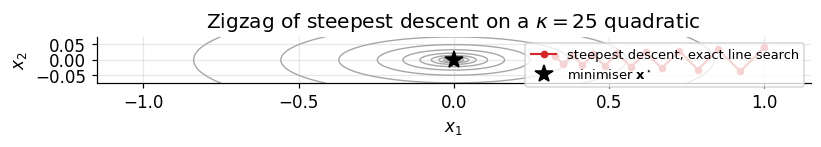

In [9]:
kappa = 25.0
A_ill = np.diag([1.0, kappa])
x_star = np.zeros(2)
A_norm_sq = lambda v: v @ A_ill @ v

x = np.array([1.0, 1.0 / kappa])   # extremal start: attains the Kantorovich bound at every step
path = [x.copy()]
errs = [A_norm_sq(x - x_star)]
for _ in range(14):
    gk = A_ill @ x
    x = x - (gk @ gk) / (gk @ A_ill @ gk) * gk
    path.append(x.copy())
    errs.append(A_norm_sq(x - x_star))

path = np.array(path)
errs = np.array(errs)
observed = errs[1:] / errs[:-1]
predicted = ((kappa - 1) / (kappa + 1))**2

print("kappa                                   =", kappa)
print("predicted factor ((k-1)/(k+1))^2        =", predicted)
print("observed contraction factors (first 5)  =", observed[:5])
print("max |observed - predicted|              =", np.max(np.abs(observed - predicted)))
print("angle between consecutive steps (deg)   =",
      np.degrees(np.arccos(np.clip(
          ((path[2]-path[1]) @ (path[1]-path[0])) /
          (np.linalg.norm(path[2]-path[1]) * np.linalg.norm(path[1]-path[0])), -1, 1))))

assert np.max(np.abs(observed - predicted)) < 1e-10

gx = np.linspace(-1.15, 1.15, 400)
gy = np.linspace(-0.075, 0.075, 400)
GX, GY = np.meshgrid(gx, gy)
GZ = 0.5 * (GX**2 + kappa * GY**2)
fig, ax = plt.subplots(figsize=(7.6, 3.4))
cs = ax.contour(GX, GY, GZ, levels=np.logspace(-4, -0.1, 12), colors="0.65", linewidths=0.9)
ax.plot(path[:, 0], path[:, 1], "o-", color="tab:red", ms=4, lw=1.4,
        label=r"steepest descent, exact line search")
ax.plot(0, 0, "k*", ms=12, label=r"minimiser $\mathbf{x}^\star$")
ax.set_aspect("equal")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title(fr"Zigzag of steepest descent on a $\kappa={kappa:.0f}$ quadratic")
ax.legend(fontsize=8.5, loc="upper right")
plt.tight_layout()
plt.show()

The observed contraction factor is $0.85207\ldots$ at every step, equal to
$((\kappa-1)/(\kappa+1))^2$ to $10^{-16}$: this starting direction attains the Kantorovich bound of
Derivation 5.6 exactly, so the bound is tight and not merely an upper estimate. Consecutive steps meet
at $90^\circ$ — the defining property of exact line search — which is what produces the visible zigzag
across the valley instead of progress along it. The lesson carried downstream is that the *direction*
of steepest descent is locally optimal (Theorem 4.2) but globally short-sighted whenever $\kappa \gg 1$.

## 8. Applications

**Electrostatics.** The electric field is the negative gradient of the scalar potential,
$\mathbf{E} = -\nabla V$. Theorem 4.2 says the field points along the direction of fastest potential
decrease; Theorem 4.3 says field lines cross equipotential surfaces at right angles, which is why
equipotentials are drawn perpendicular to field lines in every textbook figure. The work moving a
charge $q$ from $A$ to $B$ is $W = \int_{\mathcal{C}} q\mathbf{E}\cdot d\mathbf{r} = -q(V(B)-V(A))$,
path-independent by Theorem 4.4(a): the integrand is $q\frac{d}{dt}\big[-V(\mathbf{r}(t))\big]$, a total
derivative, so the integral depends only on the endpoints.

**Fourier's law of heat conduction.** The heat flux is $\mathbf{q} = -k\nabla T$ with conductivity
$k \gt 0$. Combined with conservation of energy this gives the heat equation
$\partial_t T = \alpha \Delta T$. Theorem 4.5 is the reason a body with no sources relaxes: the
Dirichlet energy $\tfrac12\int \lVert \nabla T\rVert^2$ decreases along the flow, and the heat equation
is itself the gradient flow of that energy in $L^2$.

**Fluid dynamics.** In Euler's equation $\rho \frac{D\mathbf{v}}{Dt} = -\nabla p + \rho\mathbf{g}$, the
driving force per unit volume is a pressure gradient; fluid accelerates from high toward low pressure
along the steepest-descent direction of $p$, exactly Theorem 4.2 with a sign.

**Machine learning: the loss gradient.** For empirical risk
$\mathcal{L}(\mathbf{w}) = \frac{1}{m}\sum_{i=1}^m \ell(f_{\mathbf{w}}(\mathbf{x}_i), y_i)$:

- Least squares $\mathcal{L}(\mathbf{w}) = \tfrac{1}{2m}\lVert X\mathbf{w} - \mathbf{y}\rVert^2$ has
  $\nabla \mathcal{L}(\mathbf{w}) = \tfrac1m X^\top (X\mathbf{w}-\mathbf{y})$, by Theorem 4.4(b) with
  $\mathbf{g}(\mathbf{w}) = X\mathbf{w} - \mathbf{y}$ and $J_{\mathbf{g}} = X$.
- Logistic regression with $\hat y = \sigma(\mathbf{w}^\top\mathbf{x})$ and the cross-entropy loss has
  $\nabla_{\mathbf{w}}\mathcal{L} = (\hat y - y)\mathbf{x}$ — the same chain rule, with the
  $\sigma'$ factor cancelling against the $1/(\hat y(1-\hat y))$ from the logarithm.
- **Backpropagation** is Theorem 4.4(b) run right to left. For
  $\mathbf{z}^{(l)} = W^{(l)}\mathbf{a}^{(l-1)} + \mathbf{b}^{(l)}$ and
  $\mathbf{a}^{(l)} = \sigma(\mathbf{z}^{(l)})$, the adjoint satisfies
  $\boldsymbol{\delta}^{(l)} = \big((W^{(l+1)})^\top \boldsymbol{\delta}^{(l+1)}\big) \odot \sigma'(\mathbf{z}^{(l)})$
  and $\partial\mathcal{L}/\partial W^{(l)} = \boldsymbol{\delta}^{(l)}(\mathbf{a}^{(l-1)})^\top$. Each
  $(W)^\top$ is the $J^\top$ of Theorem 4.4(b); doing the products right to left costs one forward pass
  regardless of the number of parameters, whereas left to right would cost one pass per parameter.

**Why conditioning matters in training.** The zigzag of Figure 3 is not a toy pathology: the Hessian of
a deep network's loss has condition numbers routinely in the thousands, and Derivation 5.6 says plain
steepest descent then contracts by a factor $\approx 1 - 4/\kappa$ per step. Momentum, preconditioning,
and adaptive methods all exist to change that $\kappa$.

## 9. Key Takeaways

1. If $f$ is Fréchet differentiable at $\mathbf{x}$ and $\lVert \mathbf{u}\rVert = 1$, then
   $D_{\mathbf{u}}f(\mathbf{x}) = \langle \nabla f(\mathbf{x}), \mathbf{u}\rangle$ (Theorem 4.1) — the
   $n$ partials determine every directional rate.
2. Existence of all partial derivatives, and even of all directional derivatives, does **not** imply
   differentiability; $x^3/(x^2+y^2)$ at the origin has $D_{\mathbf{u}}f = u_1^3$, not linear in
   $\mathbf{u}$ (Section 7).
3. If additionally $\nabla f(\mathbf{x}) \neq \mathbf{0}$, then $\nabla f(\mathbf{x})/\lVert \nabla f(\mathbf{x})\rVert$
   is the *unique* maximiser of $D_{\mathbf{u}}f$ over the unit sphere, with maximum value
   $\lVert \nabla f(\mathbf{x})\rVert$ (Theorem 4.2).
4. For $f$ differentiable, $\nabla f(\mathbf{x}_0) \perp T_{\mathbf{x}_0}\mathcal{S}_c$; if further
   $f \in C^1$ and $\nabla f(\mathbf{x}_0) \neq \mathbf{0}$, the tangent space is *exactly* that
   orthogonal hyperplane and the tangent hyperplane is $\langle \nabla f(\mathbf{x}_0), \mathbf{x}-\mathbf{x}_0\rangle = 0$
   (Theorem 4.3).
5. If $\mathbf{r}$ is differentiable at $t_0$ and $f$ at $\mathbf{r}(t_0)$, then
   $(f\circ\mathbf{r})'(t_0) = \langle \nabla f(\mathbf{r}(t_0)), \mathbf{r}'(t_0)\rangle$; for
   $\mathbf{g}$ differentiable, $\nabla(f\circ\mathbf{g}) = J_{\mathbf{g}}^\top \nabla f$
   (Theorem 4.4) — the statement backpropagation implements.
6. For $f \in C^1$ along a gradient-flow solution,
   $\frac{d}{dt}f(\mathbf{x}(t)) = -\lVert \nabla f(\mathbf{x}(t))\rVert^2 \le 0$, with equality only at
   stationary points (Theorem 4.5).
7. On $\tfrac12\mathbf{x}^\top\mathbf{A}\mathbf{x} - \mathbf{b}^\top\mathbf{x}$ with $\mathbf{A}\succ 0$,
   exact-line-search steepest descent contracts the squared $\mathbf{A}$-norm error by at most
   $((\kappa-1)/(\kappa+1))^2$ per step, and the bound is attained (Derivation 5.6).
8. Central differences beat forward differences by one order ($O(h^2)$ versus $O(h)$) but neither should
   be pushed below $h \approx \varepsilon^{1/3}$ resp. $\varepsilon^{1/2}$, where roundoff takes over
   (Section 7).

## 10. References

- **Apostol, T. M.** *Calculus, Volume II*, 2nd ed. §12.2 (directional derivatives), §12.4
  (Thm 12.4, the master formula $f'(\mathbf{x};\mathbf{u}) = \nabla f(\mathbf{x})\cdot\mathbf{u}$),
  §12.6 (chain rule), §12.10 (level sets and the tangent hyperplane). The reference for Theorems 4.1,
  4.3 and 4.4.
- **Rudin, W.** *Principles of Mathematical Analysis*, 3rd ed. §9.6–9.12 (Fréchet derivative and its
  uniqueness, Thm 9.15 on $C^1 \Rightarrow$ differentiable), Thm 9.28 (implicit function theorem), used
  in Proof 5.4 to identify the tangent space.
- **Spivak, M.** *Calculus on Manifolds*, Ch. 2 (Thm 2-7 for the chain rule, Thm 2-9 for the relation
  between partials and the total derivative). Coordinate-free counterpart to Definitions 3.1–3.2.
- **Marsden, J. E., & Tromba, A.** *Vector Calculus*, 6th ed. §2.6 (gradient and directional
  derivative), §2.5 (tangent planes), §4.3 (gradient fields). Geometric companion to Section 2.
- **Nocedal, J., & Wright, S. J.** *Numerical Optimization*, 2nd ed. §2.2 (steepest descent as the
  solution of $\min_{\lVert p\rVert=1} \nabla f^\top p$), §3.3 with eq. (3.29) (the
  $((\kappa-1)/(\kappa+1))^2$ rate). The reference for Theorem 4.2 and Derivation 5.6.
- **Luenberger, D. G., & Ye, Y.** *Linear and Nonlinear Programming*, 4th ed. §8.2, Thm 1 (Kantorovich
  inequality and the steepest-descent convergence theorem) — the inequality quoted in Derivation 5.6.
- **Goodfellow, I., Bengio, Y., & Courville, A.** *Deep Learning*, §4.3 (gradient-based optimisation),
  §6.5 (back-propagation as reverse-mode differentiation). The source for Section 8.
- **Higham, N. J.** *Accuracy and Stability of Numerical Algorithms*, 2nd ed. §1.11 (the
  truncation-versus-roundoff trade-off in finite differences) — the theory behind Figure 2.